<a href="https://colab.research.google.com/github/w3aarush/DR_Classification_NIT_MCA_Project/blob/main/ConvNext_Base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python

In [ ]:
import cv2
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install Kaggle API
!pip install -q kaggle

# Upload kaggle.json
from google.colab import files
files.upload()

# Setup Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# Download DATASET (not competition)
!kaggle datasets download -d mariaherrerot/aptos2019

# Unzip
!unzip -q aptos2019.zip -d aptos2019

# Check files
!ls aptos2019

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
100% 8.01G/8.01G [04:26<00:00, 32.2MB/s]

test.csv  test_images  train_1.csv  train_images  valid.csv  val_images


In [ ]:
base_dir = '/content/aptos2019'
train_dir = '/content/aptos2019/train_images/train_images/'
validation_dir = '/content/aptos2019/val_images/val_images/'
test_dir = '/content/aptos2019/test_images/test_images/'

In [ ]:
def load_data():
    train = pd.read_csv('/content/aptos2019/train_1.csv', encoding='utf-8')
    test = pd.read_csv('/content/aptos2019/test.csv', encoding='utf-8')
    valid = pd.read_csv('/content/aptos2019/valid.csv')

    train_dir = '/content/aptos2019/train_images/train_images/'
    test_dir = '/content/aptos2019/test_images/test_images/'
    valid_dir = '/content/aptos2019/val_images/val_images/'

    # construct file paths directly within function:
    train['image_path'] = train_dir + train['id_code'] + '.png'
    test['image_path'] = test_dir + test['id_code'] + '.png'
    valid['image_path'] = valid_dir + valid['id_code'] + '.png'

    train['train_images'] = train['id_code'] + '.png'
    test['test_images'] = test['id_code'] + '.png'
    valid['valid_images'] = valid['id_code'] + '.png'

    train['diagnosis'] = train['diagnosis'].astype(str)
    test['diagnosis'] = test['diagnosis'].astype(str)
    valid['diagnosis'] = valid['diagnosis'].astype(str)

    return train, test, valid

### Ben Graham Preprocessing (DFD-inspired)

As specified by your DFD, this section implements a comprehensive preprocessing function designed to prepare retinal images for analysis. The key steps included are:

1.  **Crop Borders**: Automatically detect and remove black borders, focusing on the retinal area.
2.  **Radius Normalization**: Resize the image such that the detected retina has a consistent, normalized radius across all images. This standardizes the size of the main feature.
3.  **Contrast Enhancement**: Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) to improve the visibility of details within the retina.
4.  **Circular Retina Focus**: Ensure the final output image strictly focuses on a circular region corresponding to the retina, effectively creating a standardized input for models.

First, we need to install the `opencv-python` library, which provides the necessary image manipulation tools.

In [ ]:
IMG_SIZE = 512
def benGraham(path):
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = cv2.addWeighted ( image,4, cv2.GaussianBlur( image , (0,0) , IMG_SIZE/10) ,-4 ,128)

    return image

array([[108, 108, 108, ..., 104, 104, 100],
       [108, 108, 108, ..., 104, 104, 100],
       [108, 108, 108, ..., 104, 104, 100],
       ...,
       [108, 108, 108, ..., 112, 112, 112],
       [108, 108, 108, ..., 112, 112, 112],
       [112, 112, 112, ..., 108, 108, 108]], dtype=uint8)
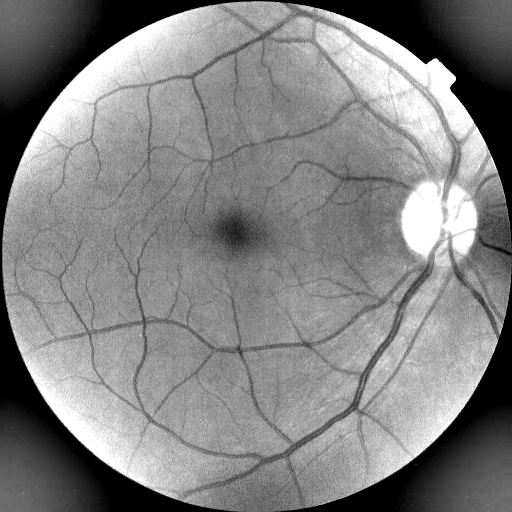

In [ ]:
benGraham('/content/aptos2019/train_images/train_images/1b398c0494d1.png')

In [ ]:
def crop_image1(img,tol=7):
    # img is image data
    # tol  is tolerance

    mask = img>tol
    return img[np.ix_(mask.any(1),mask.any(0))]

def crop_image_from_gray(img,tol=7):
    if img.ndim ==2:
        mask = img>tol
        return img[np.ix_(mask.any(1),mask.any(0))]
    elif img.ndim==3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img>tol

        check_shape = img[:,:,0][np.ix_(mask.any(1),mask.any(0))].shape[0]
        if (check_shape == 0): # image is too dark so that we crop out everything,
            return img # return original image
        else:
            img1=img[:,:,0][np.ix_(mask.any(1),mask.any(0))]
            img2=img[:,:,1][np.ix_(mask.any(1),mask.any(0))]
            img3=img[:,:,2][np.ix_(mask.any(1),mask.any(0))]
    #         print(img1.shape,img2.shape,img3.shape)
            img = np.stack([img1,img2,img3],axis=-1)
    #         print(img.shape)
        return img

In [ ]:
def crop_image(img,tol=7):
    if img.ndim ==2:
        mask = img>tol
        return img[np.ix_(mask.any(1),mask.any(0))]
    elif img.ndim==3:
        h,w,_=img.shape
#         print(h,w)
        img1=cv2.resize(crop_image1(img[:,:,0]),(w,h))
        img2=cv2.resize(crop_image1(img[:,:,1]),(w,h))
        img3=cv2.resize(crop_image1(img[:,:,2]),(w,h))

#         print(img1.shape,img2.shape,img3.shape)
        img[:,:,0]=img1
        img[:,:,1]=img2
        img[:,:,2]=img3
        return img

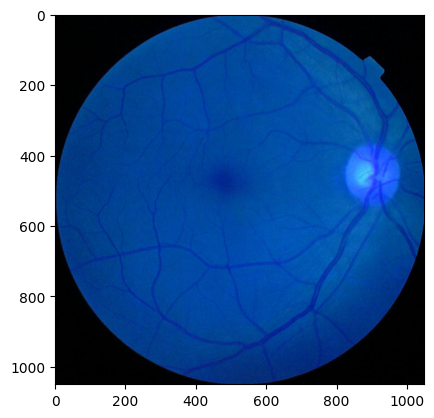

In [ ]:
img = cv2.imread('/content/aptos2019/train_images/train_images/1b398c0494d1.png')
i = crop_image(img)
# show image in i
plt.imshow(i)

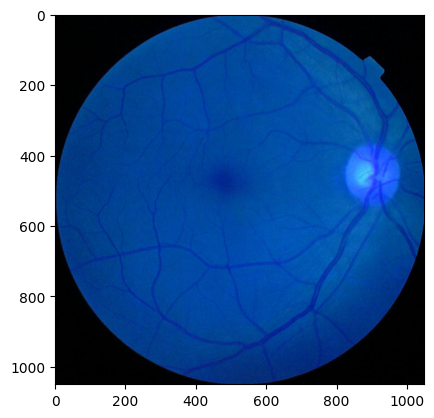

In [ ]:
plt.imshow(img)